# Notebook 06: Task-level drivers of the Gender-bearing components

The omnibus analysis identified Gender as the only metadata variable aligning with the NMF embedding, and per-component follow-up localised this to **comp_1** (anterior frontal alpha/theta) and **comp_4** (right-frontal alpha/low-beta). Because tasks were aggregated into five lobe-categories *before* NMF, the components themselves do not carry an explicit task-level breakdown.

This notebook reconstructs that breakdown. For each component of interest, we project each individual task's (channel × band) spectral profile onto the component's channel×band signature, then ask — across participants — how strongly each task's projection tracks the participant's overall loading on that component. Tasks whose projection correlates highly with the component loading are the tasks that most express the component's spatial-spectral pattern.

**This is a descriptive decomposition, not an inferential analysis.** No Gender variable enters here, and no significance hunting across tasks is performed. We report per-task Spearman correlations (with raw p-values for context only), ranked, to characterise which tasks drive comp_1 and comp_4.

**Inputs:**
- `outputs/nmf_W.csv` — participant × component embedding
- `outputs/nmf_H.csv` — component × feature loadings
- `data/eeg_features/BA*/2_emotiv_fft_values.csv` — raw per-task FFT
- `data/stimuli.csv` — task → category mapping (for task list only)

**Outputs:**
- `outputs/task_drivers_comp1.csv`, `outputs/task_drivers_comp4.csv`
- `outputs/task_drivers.png`

## Setup

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy import stats
import matplotlib.pyplot as plt
import re
import warnings
warnings.filterwarnings("ignore")

PROJECT_ROOT = Path(".").resolve().parent
DATA_DIR = PROJECT_ROOT / "data"
EEG_DIR = DATA_DIR / "eeg_features"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

COMPONENTS_OF_INTEREST = ["comp_1", "comp_4"]

FREQ_BANDS = ["Theta", "Alpha", "BetaL", "BetaH", "Gamma"]
CHANNELS = ["AF3", "F7", "F3", "FC5", "T7", "P7", "O1",
            "O2", "P8", "T8", "FC6", "F4", "F8", "AF4"]
POW_COLS = [f"POW.{ch}.{band}" for ch in CHANNELS for band in FREQ_BANDS]

## Load embedding, loadings, and task list

In [2]:
W = pd.read_csv(OUTPUT_DIR / "nmf_W.csv", index_col="participant_id")
H = pd.read_csv(OUTPUT_DIR / "nmf_H.csv", index_col=0)
stimuli = pd.read_csv(DATA_DIR / "stimuli.csv")

print(f"W shape: {W.shape}")
print(f"H shape: {H.shape}")
print(f"Tasks in stimuli.csv: {len(stimuli)}")

TASKS = stimuli["original_stimuli_name"].tolist()

def parse_feature_name(name):
    cat, pow_part = name.split("__", 1)
    _, channel, band = pow_part.split(".")
    return cat, channel, band

W shape: (86, 5)
H shape: (5, 350)
Tasks in stimuli.csv: 37


## Derive each component's channel×band signature

Each component's H row has one weight per (category, channel, band). To get a category-agnostic channel×band signature, we average each component's loadings across the five categories, yielding a single weight per (channel, band) pair. This is the pattern onto which individual tasks will be projected.

In [3]:
def component_channel_band_signature(comp):
    """Average a component's H loadings across the 5 categories -> (channel, band) -> weight."""
    row = H.loc[comp]
    recs = []
    for feat, val in row.items():
        cat, ch, band = parse_feature_name(feat)
        recs.append({"channel": ch, "band": band, "loading": val})
    df = pd.DataFrame(recs)
    sig = df.groupby(["channel", "band"])["loading"].mean()
    # Return as a vector aligned to POW_COLS order
    vec = np.array([sig.loc[(ch, band)] for ch in CHANNELS for band in FREQ_BANDS])
    return vec

signatures = {comp: component_channel_band_signature(comp) for comp in COMPONENTS_OF_INTEREST}
for comp, vec in signatures.items():
    print(f"{comp}: signature vector length {len(vec)}, "
          f"top channel×band weights:")
    order = np.argsort(vec)[::-1][:5]
    labels = [f"{ch}.{band}" for ch in CHANNELS for band in FREQ_BANDS]
    for idx in order:
        print(f"    {labels[idx]:12s} {vec[idx]:.3f}")

comp_1: signature vector length 70, top channel×band weights:
    AF3.Alpha    0.402
    AF4.Theta    0.391
    AF4.Alpha    0.382
    AF3.Theta    0.372
    AF3.BetaL    0.353
comp_4: signature vector length 70, top channel×band weights:
    F4.BetaL     0.714
    F4.Alpha     0.681
    FC6.BetaL    0.638
    O2.BetaL     0.623
    FC6.Alpha    0.613


## Build per-participant, per-task projections

For each participant and each task, we compute the median (channel × band) spectral vector for that task (same median aggregation used in Notebook 01, but per task rather than per category), then take the dot product with each component's channel×band signature. This yields, for every participant, a projection score per task per component.

Projections use the same normalization context as the main pipeline only insofar as the signature is fixed; the raw task medians are min-max scaled per feature across participants before projection so that the projection is on a comparable scale to the embedding.

In [4]:
def ba_sort_key(p):
    m = re.match(r"BA(\d+)", p.name)
    return int(m.group(1)) if m else 99999

participant_folders = sorted(
    [p for p in EEG_DIR.iterdir() if p.is_dir() and re.match(r"BA\d+", p.name)],
    key=ba_sort_key,
)

# Collect per-participant, per-task median (channel×band) vectors
# Structure: task -> participant_id -> vector(70)
task_participant_vectors = {t: {} for t in TASKS}

for folder in participant_folders:
    pid = folder.name
    if pid not in W.index:
        continue
    fpath = folder / "2_emotiv_fft_values.csv"
    if not fpath.exists():
        continue
    df = pd.read_csv(fpath)
    if "task_name" not in df.columns:
        continue
    for task in TASKS:
        sub = df[df["task_name"] == task]
        if len(sub) == 0:
            continue
        missing = [c for c in POW_COLS if c not in sub.columns]
        if missing:
            continue
        med = sub[POW_COLS].median().values  # length-70 vector
        task_participant_vectors[task][pid] = med

# Report coverage
print("Per-task participant coverage:")
for task in TASKS:
    n = len(task_participant_vectors[task])
    if n < len(W):
        print(f"  {task:35s}: {n}/{len(W)} participants")
print("(tasks not listed have full coverage)")

Per-task participant coverage:
  prefrontal1                        : 85/86 participants
  prefrontal2                        : 85/86 participants
  parietal_2d_3d                     : 84/86 participants
  parietal_next_in_seq               : 85/86 participants
  temporal_how_many_instruments1     : 82/86 participants
  temporal_how_many_instruments2     : 84/86 participants
  temporal_how_many_instruments3     : 85/86 participants
  temporal_how_many_instruments4     : 85/86 participants
  image_happy_cute                   : 85/86 participants
(tasks not listed have full coverage)


In [5]:
# Build, for each task, a participant-aligned matrix, log+winsorize+minmax per feature
# (mirrors the main pipeline transform so projections are on a comparable footing),
# then project onto each component signature.

participant_order = list(W.index)

def transform_matrix(M):
    """log1p -> per-feature winsorize 2.5/97.5 -> per-feature min-max. M is (n_participants, 70)."""
    Ml = np.log1p(M)
    lo = np.nanpercentile(Ml, 2.5, axis=0)
    hi = np.nanpercentile(Ml, 97.5, axis=0)
    Ml = np.clip(Ml, lo, hi)
    mn = np.nanmin(Ml, axis=0)
    mx = np.nanmax(Ml, axis=0)
    rng = np.where((mx - mn) == 0, 1, (mx - mn))
    return (Ml - mn) / rng

# projections[comp][task] = pd.Series indexed by participant
projections = {comp: {} for comp in COMPONENTS_OF_INTEREST}

for task in TASKS:
    pdata = task_participant_vectors[task]
    pids = [p for p in participant_order if p in pdata]
    if len(pids) < 10:
        continue
    M = np.vstack([pdata[p] for p in pids])  # (n_present, 70)
    Mt = transform_matrix(M)
    for comp in COMPONENTS_OF_INTEREST:
        sig = signatures[comp]
        proj = Mt @ sig  # dot product with signature -> length n_present
        projections[comp][task] = pd.Series(proj, index=pids)

print(f"Computed projections for {len(TASKS)} tasks x {len(COMPONENTS_OF_INTEREST)} components")

Computed projections for 37 tasks x 2 components


## Correlate per-task projection with overall component loading

For each component and task, compute the Spearman correlation (across participants) between the task's projection score and the participant's overall loading on that component. High correlation = the task strongly expresses the component's pattern, i.e., it is a driver of that component.

Raw p-values are reported for context only; this is a descriptive ranking, not a corrected inferential test.

In [6]:
def driver_table(comp):
    rows = []
    overall = W[comp]
    for task in TASKS:
        if task not in projections[comp]:
            continue
        proj = projections[comp][task]
        common = proj.index.intersection(overall.index)
        if len(common) < 10:
            continue
        rho, p = stats.spearmanr(proj.loc[common], overall.loc[common])
        rows.append({
            "task": task,
            "n": len(common),
            "spearman_rho": rho,
            "p_raw": p,
        })
    df = pd.DataFrame(rows).sort_values("spearman_rho", ascending=False).reset_index(drop=True)
    return df

driver_tables = {}
for comp in COMPONENTS_OF_INTEREST:
    df = driver_table(comp)
    driver_tables[comp] = df
    df.to_csv(OUTPUT_DIR / f"task_drivers_{comp}.csv", index=False)
    print(f"\n=== {comp} — tasks ranked by projection–loading correlation ===")
    print(df.round(4).to_string(index=False))


=== comp_1 — tasks ranked by projection–loading correlation ===
                          task  n  spearman_rho  p_raw
                  gyrus_coord2 86        0.4543 0.0000
                   gyrus_coord 86        0.4344 0.0000
               gyrus_left_open 86        0.4131 0.0001
        gyrus_left_closed_eyes 86        0.3819 0.0003
       gyrus_right_closed_eyes 86        0.3731 0.0004
               frontal3_recall 86        0.3653 0.0005
                parietal_2d_3d 84        0.3506 0.0011
              gyrus_right_open 86        0.3443 0.0012
                 baseline_talk 86        0.3331 0.0017
          parietal_next_in_seq 85        0.3273 0.0022
                        valdo1 86        0.3013 0.0048
           prefrontal3_reading 86        0.2958 0.0057
     saying_words_based_on_cat 86        0.2929 0.0062
    saying_words_based_on_cat2 86        0.2898 0.0068
         parietal_next_in_seq2 86        0.2724 0.0112
       frontal3_saying_outloud 86        0.2684 0.0125


## Visualize: tasks ranked by contribution to each component

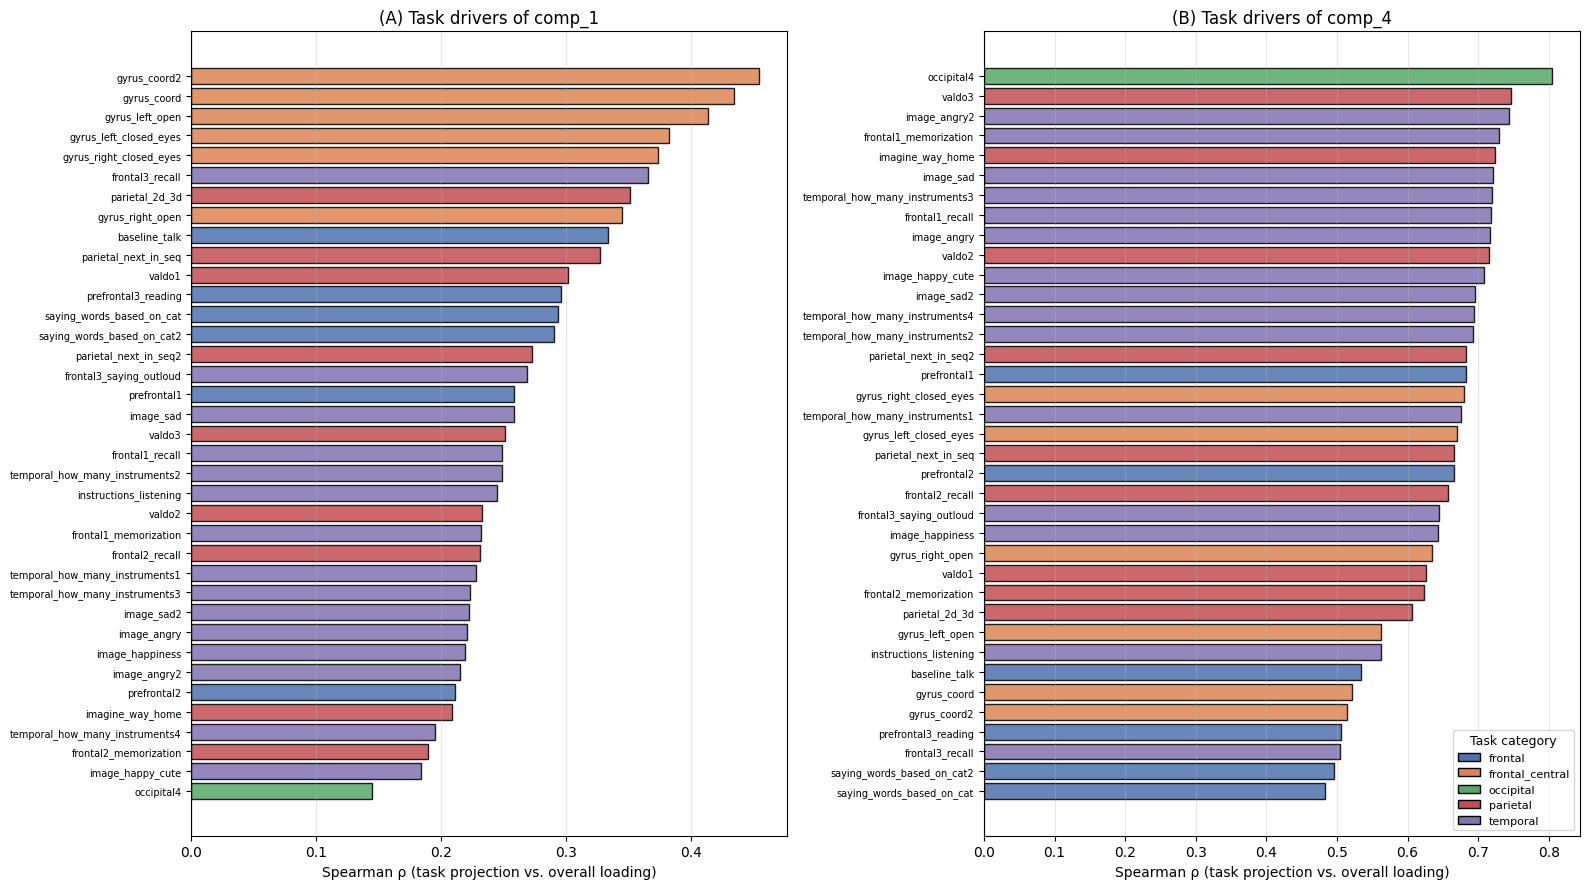

In [10]:
fig, axes = plt.subplots(1, len(COMPONENTS_OF_INTEREST), figsize=(8 * len(COMPONENTS_OF_INTEREST), 9))
if len(COMPONENTS_OF_INTEREST) == 1:
    axes = [axes]

# Category color map
def norm_cat(c):
    return str(c).strip().lower().replace("-", "_").replace(" ", "_")

CATEGORY_COLORS = {
    "frontal":         "#4C72B0",
    "frontal_central": "#DD8452",
    "occipital":       "#55A868",
    "parietal":        "#C44E52",
    "temporal":        "#8172B3",
}
task2cat = dict(zip(stimuli["original_stimuli_name"], stimuli["primary_lobe_targeted"]))

for idx, (ax, comp) in enumerate(zip(axes, COMPONENTS_OF_INTEREST)):
    df = driver_tables[comp].sort_values("spearman_rho")
    colors = [CATEGORY_COLORS.get(norm_cat(task2cat.get(t)), "#999999") for t in df["task"]]
    ax.barh(df["task"], df["spearman_rho"], color=colors, edgecolor="black", alpha=0.85)
    ax.set_xlabel("Spearman ρ (task projection vs. overall loading)")
    panel_letter = chr(ord("A") + idx)
    ax.set_title(f"({panel_letter}) Task drivers of {comp}")
    ax.axvline(0, color="black", linewidth=0.8)
    ax.grid(alpha=0.3, axis="x")
    ax.tick_params(axis="y", labelsize=7)

from matplotlib.patches import Patch
legend_handles = [Patch(facecolor=c, edgecolor="black", label=cat)
                  for cat, c in CATEGORY_COLORS.items()]
axes[-1].legend(handles=legend_handles, title="Task category",
                loc="lower right", fontsize=8, title_fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "task_drivers.png", dpi=150, bbox_inches="tight")
plt.show()

## Summary

The tables and figure above rank all tasks by how strongly their isolated spectral profile expresses each Gender-bearing component's channel×band signature. Tasks at the top of each ranking are the strongest task-level drivers of that component.

Interpretation should remain descriptive: these correlations indicate where in the task battery the comp_1 (anterior frontal alpha/theta) and comp_4 (right-frontal alpha/low-beta) patterns are most strongly expressed. They do not constitute independent significance tests, and the Gender association itself remains established at the component level (Notebooks 04–05), not re-tested here.

In [8]:
print("=" * 60)
print("TASK-DRIVER SUMMARY")
print("=" * 60)
for comp in COMPONENTS_OF_INTEREST:
    df = driver_tables[comp]
    top5 = df.head(5)
    print(f"\n{comp}: top 5 task drivers")
    for _, row in top5.iterrows():
        print(f"  {row['task']:35s} rho={row['spearman_rho']:.3f} (p_raw={row['p_raw']:.4f}, n={int(row['n'])})")

print("\nFiles saved:")
for comp in COMPONENTS_OF_INTEREST:
    print(f"  task_drivers_{comp}.csv")
print("  task_drivers.png")

TASK-DRIVER SUMMARY

comp_1: top 5 task drivers
  gyrus_coord2                        rho=0.454 (p_raw=0.0000, n=86)
  gyrus_coord                         rho=0.434 (p_raw=0.0000, n=86)
  gyrus_left_open                     rho=0.413 (p_raw=0.0001, n=86)
  gyrus_left_closed_eyes              rho=0.382 (p_raw=0.0003, n=86)
  gyrus_right_closed_eyes             rho=0.373 (p_raw=0.0004, n=86)

comp_4: top 5 task drivers
  occipital4                          rho=0.804 (p_raw=0.0000, n=86)
  valdo3                              rho=0.746 (p_raw=0.0000, n=86)
  image_angry2                        rho=0.743 (p_raw=0.0000, n=86)
  frontal1_memorization               rho=0.729 (p_raw=0.0000, n=86)
  imagine_way_home                    rho=0.724 (p_raw=0.0000, n=86)

Files saved:
  task_drivers_comp_1.csv
  task_drivers_comp_4.csv
  task_drivers.png
